In [1]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt

In [2]:
# Load dataset
vocab_size = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

# Padding
max_len = 200
X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
# Model
model = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train
history = model.fit(X_train, y_train, epochs=3, batch_size=64, validation_split=0.2)

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 89s 271ms/step - accuracy: 0.8025 - loss: 0.4240 - val_accuracy: 0.8698 - val_loss: 0.3234
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 266ms/step - accuracy: 0.9030 - loss: 0.2489 - val_accuracy: 0.8624 - val_loss: 0.3321
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 88s 280ms/step - accuracy: 0.9323 - loss: 0.1773 - val_accuracy: 0.8670 - val_loss: 0.3296


In [5]:
# Evaluate
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 36ms/step - accuracy: 0.8544 - loss: 0.3539
Accuracy: 0.8544399738311768


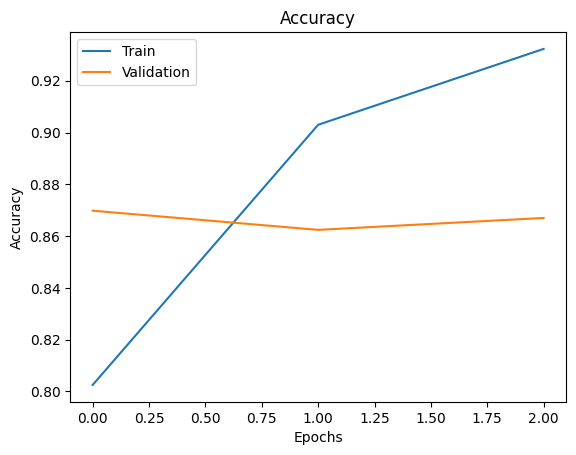

In [6]:
# Plot Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

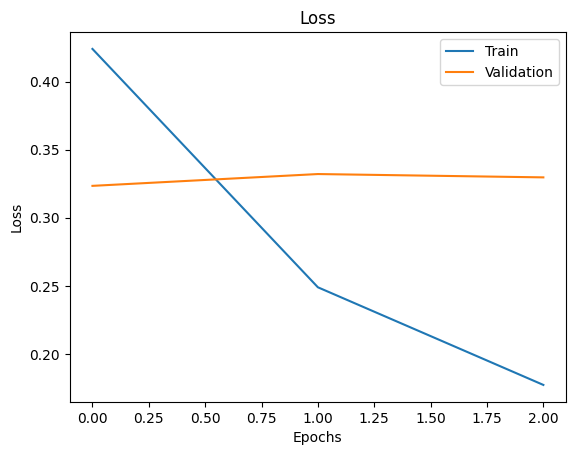

In [7]:
# Plot Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()